# Feature Engineering Notebook
## South African Residential Property Investment ML Project

### Objective
In this notebook, I take the output of the financial engine and transform it into a modelling-ready dataset.

The purpose is not to create random predictors. The purpose is to create features that improve the model's ability to distinguish between weak, moderate, and strong financed property investments.

This notebook stays anchored to the actual business problem:

- I am evaluating **buy-to-let residential property deals**
- The investor is typically **financing the purchase through a bank bond**
- The model must learn which deals are financially viable based on:
  - acquisition price
  - rental strength
  - size and layout
  - operating cost burden
  - leverage structure
  - debt affordability
  - market context
  - confidence in the rental estimate

The output of this notebook will be a clean engineered dataset that can be used in the next stage:
**feature selection + train/validation/test modelling**

# 1. Imports and setup

In [54]:

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Load dataset

I start from the financial engine output because it already contains:

- cleaned property listing fields
- rental estimation outputs
- financing assumptions
- operating cost calculations
- financial outputs such as NOI, cash flow, DSCR, yield and ROI

At this stage, I am not rebuilding the financial engine.
I am engineering additional predictive structure on top of it.

Important:
Some financial-engine outputs are very close to the final decision label.
That means I must separate:

- columns that are safe as predictors
- columns that create leakage

# 2. Load data

In [55]:
DATA_PATH = Path("data\interim\financial_engine_sales_dataset.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (9009, 75)


,source_site,listing_id,listing_url,title,purchase_price,suburb,city,province,property_type,bedrooms,bathrooms,parking_spaces,garage,floor_area_sqm,land_area_sqm,levies,rates_taxes,description,listing_date,scraped_timestamp,pp_transaction_slug,pp_province_slug,pp_metro_slug,pp_city_slug,pp_suburb_slug,purchase_price_rands,rent_median_suburb_type_bed,rent_mean_suburb_type_bed,rent_count_suburb_type_bed,rent_median_suburb_bed,rent_mean_suburb_bed,rent_count_suburb_bed,rent_median_suburb,rent_mean_suburb,rent_count_suburb,rent_median_city_type_bed,rent_mean_city_type_bed,rent_count_city_type_bed,rent_median_city,rent_mean_city,rent_count_city,rent_median_province,rent_mean_province,rent_count_province,estimated_monthly_rent,rent_estimation_source,deposit_pct,deposit_amount,transfer_cost_rate,transfer_costs,total_cash_invested,loan_amount,annual_interest_rate,loan_term_years,bond_payment,other_income,gross_income,levies_clean,rates_taxes_clean,maintenance_rate,vacancy_rate,maintenance_cost,vacancy_cost,total_expenses,NOI,cash_flow,DSCR,annual_rent,rental_yield,annual_cash_flow,ROI,payments_made_12m,remaining_balance_12m,equity_12m,investment_label
0,privateproperty,T5332132,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Broadacres,"890,000.0000",Broadacres,Sandton,Gauteng,Apartment,2.0000,2.0000,1.0000,NaN,85.0000,5.0000,"2,693.0000",840.0000,"2 Bedroom Apartment in Broadacres, Airbnb Oppo...",11 Dec 2025,2026-03-27T16:32:22.940146+00:00,for-sale,gauteng,johannesburg-metro,sandton,broadacres,"890,000.0000","10,700.0000","12,899.9231",13.0000,"12,100.0000","14,079.9714",35.0000,"15,950.0000","18,588.6698",106.0000,"10,750.0000","15,520.0678",354.0000,"19,900.0000","27,643.2692",3555,"12,400.0000","19,322.0406",10000,"10,700.0000",suburb_property_type_bedrooms,0.1000,"89,000.0000",0.0800,"71,200.0000","160,200.0000","801,000.0000",0.1100,20,"8,267.8290",0.0000,"10,700.0000","2,693.0000",840.0000,0.0800,0.0500,856.0000,535.0000,"4,924.0000","5,776.0000","-2,491.8290",0.6986,"128,400.0000",0.1443,"-29,901.9483",-0.1867,12,"789,318.7639","100,681.2361",Weak Investment
1,privateproperty,T5405954,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Sundowner,"885,000.0000",Sundowner,North Riding To Lanseria,Gauteng,Apartment,2.0000,1.0000,1.0000,NaN,105.0000,NaN,"1,741.5000",446.0000,"2 Bedroom Apartment in Sundowner, High-demand,...",27 Feb 2026,2026-03-27T16:32:19.698613+00:00,for-sale,gauteng,johannesburg-metro,north-riding-to-lanseria,sundowner,"885,000.0000",NaN,NaN,NaN,"18,200.0000","17,883.3333",6.0000,"20,350.0000","21,887.5000",16.0000,"8,800.0000","8,967.1515",33.0000,"10,613.0000","15,140.4980",494,"12,400.0000","19,322.0406",10000,"18,200.0000",suburb_bedrooms,0.1000,"88,500.0000",0.0800,"70,800.0000","159,300.0000","796,500.0000",0.1100,20,"8,221.3805",0.0000,"18,200.0000","1,741.5000",446.0000,0.0800,0.0500,"1,456.0000",910.0000,"4,553.5000","13,646.5000","5,425.1195",1.6599,"218,400.0000",0.2468,"65,101.4335",0.4087,12,"784,884.3888","100,115.6112",Strong Investment
2,privateproperty,T5374159,https://www.privateproperty.co.za/for-sale/gau...,2 Bedroom Apartment in Jackal Creek Golf Estate,"880,000.0000",Jackal Creek Northriding,North Riding To Lanseria,Gauteng,Apartment,2.0000,2.0000,3.0000,NaN,71.0000,NaN,"2,696.0000",540.0000,2 Bedroom Apartment in Jackal Creek Golf Estat...,3 Feb 2026,2026-03-27T16:32:15.389505+00:00,for-sale,gauteng,johannesburg-metro,north-riding-to-lanseria,jackal-creek-northriding,"880,000.0000","6,650.0000","6,650.0000",2.0000,"9,050.0000","11,570.0000",5.0000,"16,000.0000","13,813.7931",29.0000,"8,800.0000","8,967.1515",33.0000,"10,613.0000","15,140.4980",494,"12,400.0000","19,322.0406",10000,"6,650.0000",suburb_property_type_bedrooms,0.1000,"88,000.0000",0.0800,"70,400.0000","158,400.0000","792,000.0000",0.1100,20,"8,174.9321",0.0000,"6,650.0000","2,696.0000",540.0000,0.0800,0.0500,532.0000,332.5000,"4,100.5000","2,549.5000","-5,625.4321",0.3119,"79,8

## Why this feature engineering matters for this project

A property investment deal is not judged by price alone.

A financed deal becomes attractive only when the relationship between the following makes sense:

1. **Purchase economics**
   - purchase price
   - price efficiency per square meter
   - price relative to number of bedrooms/bathrooms

2. **Rental strength**
   - expected monthly rent
   - annual rent
   - rent relative to purchase price
   - rent relative to size

3. **Operating burden**
   - levies
   - rates and taxes
   - maintenance
   - vacancy drag
   - total expenses

4. **Leverage and affordability**
   - loan amount
   - deposit amount
   - LTV
   - bond repayment burden
   - DSCR
   - cash flow after debt service

5. **Market confidence**
   - how strong the rent estimation evidence is
   - whether the rent estimate came from suburb/type/bedroom level or broader fallback levels
   - how many comparable rental observations were available

That is what I want the model to learn.

So my engineered features will focus on:
- valuation efficiency
- rental efficiency
- operating efficiency
- leverage structure
- affordability under debt
- reliability of the rent estimate
- local market context

# 3 Quick structure check

In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9009 entries, 0 to 9008
Data columns (total 75 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   source_site                  9009 non-null   object 
 1   listing_id                   9009 non-null   object 
 2   listing_url                  9009 non-null   object 
 3   title                        9009 non-null   object 
 4   purchase_price               9009 non-null   float64
 5   suburb                       9009 non-null   object 
 6   city                         9009 non-null   object 
 7   province                     9009 non-null   object 
 8   property_type                9009 non-null   object 
 9   bedrooms                     9009 non-null   float64
 10  bathrooms                    9009 non-null   float64
 11  parking_spaces               8892 non-null   float64
 12  garage                       8452 non-null   float64
 13  floor_area_sqm    

In [58]:
# Basic preview of missingness
missing_summary = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("missing_pct")
      .to_frame()
)

missing_summary.head(30)

,missing_pct
rent_median_suburb_type_bed,0.2368
rent_mean_suburb_type_bed,0.2368
rent_count_suburb_type_bed,0.2368
rent_median_suburb_bed,0.1856
rent_mean_suburb_bed,0.1856
rent_count_suburb_bed,0.1856
rent_count_suburb,0.1132
rent_median_suburb,0.1132
rent_mean_suburb,0.1132
garage,0.0618


## Initial observation

Before engineering new features, I want to understand:

- what data types I currently have
- which columns have meaningful missingness
- whether the main financial columns are populated
- whether there are obvious fields I should exclude from modelling later

## 5. Assign columns by role

To keep the project disciplined, I classify columns into groups.

### A. Identifier / metadata columns
These help with traceability but should not be used as predictors:
- listing_id
- listing_url
- title
- description
- scraped timestamps and slug metadata

### B. Raw property features
These describe the asset:
- suburb, city, province, property_type
- bedrooms, bathrooms, parking, garage
- floor area, land area
- purchase price

### C. Rental market evidence
These describe local rental benchmarks used by the engine:
- suburb / city / province rent medians and means
- rent counts
- estimated monthly rent
- rent estimation source

### D. Financing and operating assumptions
These describe the financed structure:
- deposit
- loan amount
- transfer costs
- interest rate
- bond payment
- levies, rates, maintenance, vacancy

### E. Financial outputs
These are the outputs of the core financial engine:
- NOI
- cash_flow
- DSCR
- rental_yield
- ROI
- equity_12m
- investment_label

These last columns are extremely important for business interpretation.
But if I later predict investment_label, many of them become leakage columns.
So I keep them for EDA and evaluation, but I do not blindly feed them into modelling.

In [63]:
id_cols = [
    "source_site", "listing_id", "listing_url", "title", "description",
    "listing_date", "scraped_timestamp",
    "pp_transaction_slug", "pp_province_slug", "pp_metro_slug",
    "pp_city_slug", "pp_suburb_slug"
]

location_cols = ["suburb", "city", "province", "property_type"]

property_cols = [
    "purchase_price", "purchase_price_rands",
    "bedrooms", "bathrooms", "parking_spaces", "garage",
    "floor_area_sqm", "land_area_sqm"
]

rent_benchmark_cols = [
    "rent_median_suburb_type_bed", "rent_mean_suburb_type_bed", "rent_count_suburb_type_bed",
    "rent_median_suburb_bed", "rent_mean_suburb_bed", "rent_count_suburb_bed",
    "rent_median_suburb", "rent_mean_suburb", "rent_count_suburb",
    "rent_median_city_type_bed", "rent_mean_city_type_bed", "rent_count_city_type_bed",
    "rent_median_city", "rent_mean_city", "rent_count_city",
    "rent_median_province", "rent_mean_province", "rent_count_province",
    "estimated_monthly_rent", "rent_estimation_source"
]

finance_cols = [
    "deposit_pct", "deposit_amount", "transfer_cost_rate", "transfer_costs",
    "total_cash_invested", "loan_amount", "annual_interest_rate", "loan_term_years",
    "bond_payment", "other_income", "gross_income"
]

opex_cols = [
    "levies", "rates_taxes", "levies_clean", "rates_taxes_clean",
    "maintenance_rate", "vacancy_rate", "maintenance_cost", "vacancy_cost",
    "total_expenses"
]

financial_output_cols = [
    "NOI", "cash_flow", "DSCR", "annual_rent", "rental_yield",
    "annual_cash_flow", "ROI", "payments_made_12m", "remaining_balance_12m",
    "equity_12m", "investment_label"
]

existing_cols = set(df.columns)

for name, cols in {
    "id_cols": id_cols,
    "location_cols": location_cols,
    "property_cols": property_cols,
    "rent_benchmark_cols": rent_benchmark_cols,
    "finance_cols": finance_cols,
    "opex_cols": opex_cols,
    "financial_output_cols": financial_output_cols
}.items():
    missing = [c for c in cols if c not in existing_cols]
    if missing:
        print(f"{name} missing from dataset:", missing)

# 5.Data quality checks before feature engineering

In [62]:
checks = {
    "negative purchase price": (df["purchase_price"] <= 0).sum(),
    "negative estimated rent": (df["estimated_monthly_rent"] <= 0).sum(),
    "negative bond payment": (df["bond_payment"] < 0).sum(),
    "negative floor area": (df["floor_area_sqm"] < 0).sum(),
    "zero/negative gross income": (df["gross_income"] <= 0).sum(),
    "negative loan amount": (df["loan_amount"] < 0).sum(),
    "negative total cash invested": (df["total_cash_invested"] < 0).sum(),
}

pd.Series(checks, name="issue_count")

negative purchase price         0
negative estimated rent         0
negative bond payment           0
negative floor area             0
zero/negative gross income      0
negative loan amount            0
negative total cash invested    0
Name: issue_count, dtype: int64

## Why I do this now

I need to protect the logic of downstream features.

For example:
- price per sqm breaks if floor area is zero
- leverage ratios break if purchase price is zero
- affordability ratios break if gross income is zero

So I create safe division rules before engineering anything else.

# 6. Helper functions

In [64]:

def safe_divide(numerator, denominator):
    """
    Elementwise safe division.
    Returns NaN where denominator is 0 or missing.
    """
    numerator = pd.Series(numerator)
    denominator = pd.Series(denominator)
    return np.where(
        (denominator.notna()) & (denominator != 0),
        numerator / denominator,
        np.nan
    )

def winsorize_series(s, lower=0.01, upper=0.99):
    """
    Caps a numeric series at selected quantiles.
    """
    if s.dropna().empty:
        return s
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)

def add_missing_flag(frame, col):
    frame[f"{col}_missing_flag"] = frame[col].isna().astype(int)
    return frame

# 7) Feature Engineering

I now create project-specific features in five groups:

1. **Property structure features**
2. **Pricing efficiency features**
3. **Rental strength and market-relative features**
4. **Operating and financing burden features**
5. **Confidence and evidence features**

The goal is to turn raw columns into variables that express how an investor actually thinks about a deal.

In [65]:
# Work on a copy
fe = df.copy()

## 7.1 Property structure features

These features describe the physical profile of the property more meaningfully than raw counts alone.

Why they matter:
- the rental market often responds to layout, not just total size
- price differences can reflect bedroom density and usable area
- size efficiency matters for small investors comparing entry-level deals

In [66]:
fe["total_rooms_proxy"] = (
    fe["bedrooms"].fillna(0)
    + fe["bathrooms"].fillna(0)
)

fe["floor_to_land_ratio"] = safe_divide(fe["floor_area_sqm"], fe["land_area_sqm"])
fe["bedroom_density_floor"] = safe_divide(fe["bedrooms"], fe["floor_area_sqm"])
fe["bathroom_density_floor"] = safe_divide(fe["bathrooms"], fe["floor_area_sqm"])
fe["parking_total"] = fe["parking_spaces"].fillna(0) + fe["garage"].fillna(0)
fe["parking_per_bedroom"] = safe_divide(fe["parking_total"], fe["bedrooms"])

fe["is_compact_unit"] = (
    (fe["floor_area_sqm"].fillna(np.inf) <= 80).astype(int)
)

fe["is_family_sized_unit"] = (
    ((fe["bedrooms"] >= 3) & (fe["floor_area_sqm"].fillna(0) >= 100)).astype(int)
)

fe["is_large_land_property"] = (
    (fe["land_area_sqm"].fillna(0) >= fe["land_area_sqm"].quantile(0.75)).astype(int)
)

## 7.2 Pricing efficiency features

For this project, purchase price alone is not enough.

I need to know whether the property is:
- expensive relative to its size
- expensive relative to its bedroom count
- expensive relative to local rental earning power

These are closer to investor decision logic than raw purchase price.

In [67]:
price_base = "purchase_price"

fe["price_per_sqm"] = safe_divide(fe[price_base], fe["floor_area_sqm"])
fe["price_per_land_sqm"] = safe_divide(fe[price_base], fe["land_area_sqm"])
fe["price_per_bedroom"] = safe_divide(fe[price_base], fe["bedrooms"])
fe["price_per_bathroom"] = safe_divide(fe[price_base], fe["bathrooms"])

# Local relative pricing
fe["price_vs_suburb_median_rent_multiple"] = safe_divide(fe[price_base], fe["rent_median_suburb"] * 12)
fe["price_vs_city_median_rent_multiple"] = safe_divide(fe[price_base], fe["rent_median_city"] * 12)

# Compare listing price to local typical price-per-sqm within suburb/property_type where possible
suburb_type_ppsqm = (
    fe.groupby(["suburb", "property_type"])["price_per_sqm"]
      .median()
      .rename("suburb_type_median_price_per_sqm")
      .reset_index()
)

fe = fe.merge(suburb_type_ppsqm, on=["suburb", "property_type"], how="left")

fe["price_per_sqm_vs_local_median"] = safe_divide(
    fe["price_per_sqm"], fe["suburb_type_median_price_per_sqm"]
)

## 7.3 Rental strength features

This is one of the most important feature groups in the entire project.

The project is about financed buy-to-let viability.
That means the rent side of the deal carries the model.

I want to know:
- how much rent the asset earns relative to price
- how rent-efficient the unit is per sqm and per bedroom
- whether the rent estimate is above or below local benchmarks

In [68]:
fe["rent_per_sqm"] = safe_divide(fe["estimated_monthly_rent"], fe["floor_area_sqm"])
fe["rent_per_bedroom"] = safe_divide(fe["estimated_monthly_rent"], fe["bedrooms"])
fe["rent_per_bathroom"] = safe_divide(fe["estimated_monthly_rent"], fe["bathrooms"])

fe["gross_rent_to_price"] = safe_divide(fe["annual_rent"], fe[price_base])
fe["monthly_rent_to_price"] = safe_divide(fe["estimated_monthly_rent"], fe[price_base])

fe["rent_vs_suburb_median"] = safe_divide(fe["estimated_monthly_rent"], fe["rent_median_suburb"])
fe["rent_vs_city_median"] = safe_divide(fe["estimated_monthly_rent"], fe["rent_median_city"])
fe["rent_vs_province_median"] = safe_divide(fe["estimated_monthly_rent"], fe["rent_median_province"])

fe["rent_vs_suburb_type_bed_median"] = safe_divide(
    fe["estimated_monthly_rent"], fe["rent_median_suburb_type_bed"]
)

fe["rent_vs_suburb_bed_median"] = safe_divide(
    fe["estimated_monthly_rent"], fe["rent_median_suburb_bed"]
)

fe["annual_rent_per_sqm"] = safe_divide(fe["annual_rent"], fe["floor_area_sqm"])

## 7.4 Operating burden features

A deal can look strong on gross yield and still fail after costs.

That is especially true in sectional title and levied properties, where:
- levies are high
- rates and taxes are meaningful
- vacancy and maintenance drag reduce true cash generation

These features convert raw cost fields into burden ratios.

In [69]:
fe["levies_to_rent"] = safe_divide(fe["levies_clean"], fe["estimated_monthly_rent"])
fe["rates_to_rent"] = safe_divide(fe["rates_taxes_clean"], fe["estimated_monthly_rent"])
fe["bond_to_rent"] = safe_divide(fe["bond_payment"], fe["estimated_monthly_rent"])

fe["maintenance_to_rent"] = safe_divide(fe["maintenance_cost"], fe["estimated_monthly_rent"])
fe["vacancy_to_rent"] = safe_divide(fe["vacancy_cost"], fe["estimated_monthly_rent"])
fe["opex_to_rent"] = safe_divide(fe["total_expenses"], fe["estimated_monthly_rent"])
fe["opex_to_income"] = safe_divide(fe["total_expenses"], fe["gross_income"])

fe["noi_margin"] = safe_divide(fe["NOI"], fe["gross_income"])
fe["cash_flow_margin"] = safe_divide(fe["cash_flow"], fe["gross_income"])

fe["fixed_cost_burden"] = safe_divide(
    fe["levies_clean"] + fe["rates_taxes_clean"] + fe["bond_payment"],
    fe["estimated_monthly_rent"]
)

fe["non_debt_opex"] = (
    fe["total_expenses"]
    - fe["bond_payment"]
)

fe["non_debt_opex_to_rent"] = safe_divide(fe["non_debt_opex"], fe["estimated_monthly_rent"])

## 7.5 Financing and leverage features

This project is explicitly about financed acquisitions.

So leverage is not a side issue.
It is central to the problem.

I want the model to understand:
- how highly geared the deal is
- how much cash the investor needs upfront
- whether debt service is covered comfortably
- whether the structure is tight, balanced, or risky

In [70]:
fe["ltv"] = safe_divide(fe["loan_amount"], fe[price_base])
fe["deposit_to_price"] = safe_divide(fe["deposit_amount"], fe[price_base])
fe["cash_invested_to_price"] = safe_divide(fe["total_cash_invested"], fe[price_base])
fe["transfer_costs_to_price"] = safe_divide(fe["transfer_costs"], fe[price_base])

fe["bond_payment_to_income"] = safe_divide(fe["bond_payment"], fe["gross_income"])
fe["bond_payment_to_noi"] = safe_divide(fe["bond_payment"], fe["NOI"])

fe["cash_flow_to_cash_invested"] = safe_divide(fe["annual_cash_flow"], fe["total_cash_invested"])
fe["equity_12m_to_cash_invested"] = safe_divide(fe["equity_12m"], fe["total_cash_invested"])

fe["debt_service_headroom"] = fe["DSCR"] - 1
fe["positive_cash_flow_flag"] = (fe["cash_flow"] > 0).astype(int)
fe["dscr_above_one_flag"] = (fe["DSCR"] > 1).astype(int)
fe["dscr_above_1_2_flag"] = (fe["DSCR"] > 1.2).astype(int)

## 7.6 Rent evidence and confidence features

Rental estimation confidence is critical.

If the rent estimate was derived from:
- suburb + property type + bedrooms with enough observations,
that is stronger evidence than:
- broad city fallback
or
- province fallback

This matters because weak evidence can make a deal look attractive on paper while being less reliable in practice.

In [71]:
source_rank = {
    "suburb_property_type_bedrooms": 5,
    "suburb_bedrooms": 4,
    "suburb": 3,
    "city_property_type_bedrooms": 2,
    "city": 1
}

fe["rent_source_score"] = fe["rent_estimation_source"].map(source_rank).fillna(0)

# best available count proxy based on source
fe["rent_estimate_observation_count"] = np.select(
    [
        fe["rent_estimation_source"].eq("suburb_property_type_bedrooms"),
        fe["rent_estimation_source"].eq("suburb_bedrooms"),
        fe["rent_estimation_source"].eq("suburb"),
        fe["rent_estimation_source"].eq("city_property_type_bedrooms"),
        fe["rent_estimation_source"].eq("city")
    ],
    [
        fe["rent_count_suburb_type_bed"],
        fe["rent_count_suburb_bed"],
        fe["rent_count_suburb"],
        fe["rent_count_city_type_bed"],
        fe["rent_count_city"]
    ],
    default=np.nan
)

fe["rent_estimate_low_evidence_flag"] = (
    fe["rent_estimate_observation_count"].fillna(0) < 10
).astype(int)

fe["rent_estimate_high_evidence_flag"] = (
    fe["rent_estimate_observation_count"].fillna(0) >= 30
).astype(int)

fe["rent_dispersion_suburb_type_bed"] = safe_divide(
    fe["rent_mean_suburb_type_bed"] - fe["rent_median_suburb_type_bed"],
    fe["rent_median_suburb_type_bed"]
)

fe["rent_dispersion_suburb"] = safe_divide(
    fe["rent_mean_suburb"] - fe["rent_median_suburb"],
    fe["rent_median_suburb"]
)

fe["rent_dispersion_city"] = safe_divide(
    fe["rent_mean_city"] - fe["rent_median_city"],
    fe["rent_median_city"]
)

## 7.7 Local market context features

These features help the model understand whether the property sits in a more expensive, deeper, or thinner local market.

That matters because:
- deep rental markets may be more stable
- thin rental markets may create more risk
- high-rent areas can still be poor deals if price is too stretched

In [72]:
suburb_listing_count = fe.groupby("suburb")["listing_id"].transform("count")
city_listing_count = fe.groupby("city")["listing_id"].transform("count")
property_type_count = fe.groupby("property_type")["listing_id"].transform("count")

fe["suburb_listing_density"] = suburb_listing_count
fe["city_listing_density"] = city_listing_count
fe["property_type_density"] = property_type_count

fe["suburb_price_median"] = fe.groupby("suburb")[price_base].transform("median")
fe["city_price_median"] = fe.groupby("city")[price_base].transform("median")

fe["price_vs_suburb_price_median"] = safe_divide(fe[price_base], fe["suburb_price_median"])
fe["price_vs_city_price_median"] = safe_divide(fe[price_base], fe["city_price_median"])

fe["suburb_rent_median_feature"] = fe.groupby("suburb")["estimated_monthly_rent"].transform("median")
fe["city_rent_median_feature"] = fe.groupby("city")["estimated_monthly_rent"].transform("median")

fe["rent_vs_suburb_internal_median"] = safe_divide(
    fe["estimated_monthly_rent"], fe["suburb_rent_median_feature"]
)

fe["rent_vs_city_internal_median"] = safe_divide(
    fe["estimated_monthly_rent"], fe["city_rent_median_feature"]
)

## 7.8 Missingness as information

In property data, missingness can itself carry information.

Examples:
- missing floor area may indicate lower listing quality
- missing land area may be more common in sectional title units
- missing garage count may not be random

Instead of dropping this information, I keep missingness flags for fields that may matter.

In [73]:
flag_cols = [
    "floor_area_sqm",
    "land_area_sqm",
    "garage",
    "parking_spaces",
    "rent_median_suburb_type_bed",
    "rent_median_suburb_bed",
    "rent_median_suburb",
    "rent_median_city_type_bed"
]

for c in flag_cols:
    if c in fe.columns:
        fe = add_missing_flag(fe, c)

## 7.9 Winsorisation strategy

I do not want to blindly clip everything.

For this project, some extreme values are real:
- luxury properties
- very large homes
- unusually strong rents in top-end suburbs

But some ratios can explode due to:
- tiny denominators
- sparse market evidence
- unusual scraped values

So I create winsorised versions only for ratio features that are likely to destabilise modelling.
I keep the raw version as well for auditability.

In [74]:
winsor_cols = [
    "price_per_sqm",
    "price_per_land_sqm",
    "rent_per_sqm",
    "gross_rent_to_price",
    "monthly_rent_to_price",
    "levies_to_rent",
    "rates_to_rent",
    "bond_to_rent",
    "opex_to_rent",
    "cash_flow_margin",
    "ltv",
    "bond_payment_to_income",
    "debt_service_headroom",
    "price_per_sqm_vs_local_median",
    "rent_vs_suburb_median",
    "rent_vs_city_median",
    "price_vs_suburb_price_median",
    "price_vs_city_price_median"
]

for c in winsor_cols:
    if c in fe.columns:
        fe[f"{c}_win"] = winsorize_series(fe[c], 0.01, 0.99)

## 7.10 Categorical standardisation

The next modelling notebook will likely use encoding on categoricals.
So I standardise text columns now to reduce category fragmentation.

In [75]:
cat_cols = ["suburb", "city", "province", "property_type", "rent_estimation_source", "investment_label"]

for c in cat_cols:
    if c in fe.columns:
        fe[c] = (
            fe[c]
            .astype(str)
            .str.strip()
        )

fe["property_type"] = fe["property_type"].str.title()
fe["province"] = fe["province"].str.title()
fe["city"] = fe["city"].str.title()
fe["suburb"] = fe["suburb"].str.title()

# 8 Leakage control

This section is critical.

The final model must predict investment quality without cheating.

If my target is `investment_label`, then the following fields are not safe predictors because they are either direct outputs of the financial engine or are mathematically too close to the label:

- NOI
- cash_flow
- DSCR
- annual_cash_flow
- rental_yield
- ROI
- equity_12m
- payments_made_12m
- remaining_balance_12m

Also, engineered features built directly from these should be used carefully depending on the modelling target.

### Rule I will use
- Keep these columns in the dataset for business interpretation and EDA
- Exclude them from the predictor set in the modelling notebook when predicting `investment_label`

In [76]:
target_col = "investment_label"

direct_leakage_cols = [
    "NOI",
    "cash_flow",
    "DSCR",
    "annual_cash_flow",
    "rental_yield",
    "ROI",
    "equity_12m",
    "payments_made_12m",
    "remaining_balance_12m"
]

# Engineered columns that may also be leakage if target = investment_label
derived_from_outputs_cols = [
    "noi_margin",
    "cash_flow_margin",
    "cash_flow_to_cash_invested",
    "equity_12m_to_cash_invested",
    "debt_service_headroom",
    "positive_cash_flow_flag",
    "dscr_above_one_flag",
    "dscr_above_1_2_flag",
    "bond_payment_to_noi"
]

leakage_watchlist = direct_leakage_cols + derived_from_outputs_cols

print("Direct leakage columns present:")
print([c for c in leakage_watchlist if c in fe.columns])

Direct leakage columns present:
['NOI', 'cash_flow', 'DSCR', 'annual_cash_flow', 'rental_yield', 'ROI', 'equity_12m', 'payments_made_12m', 'remaining_balance_12m', 'noi_margin', 'cash_flow_margin', 'cash_flow_to_cash_invested', 'equity_12m_to_cash_invested', 'debt_service_headroom', 'positive_cash_flow_flag', 'dscr_above_one_flag', 'dscr_above_1_2_flag', 'bond_payment_to_noi']


In [77]:
new_feature_cols = [c for c in fe.columns if c not in df.columns]

print("Number of newly engineered features:", len(new_feature_cols))
pd.Series(new_feature_cols).sort_values().to_list()[:200]

Number of newly engineered features: 96


['annual_rent_per_sqm',
 'bathroom_density_floor',
 'bedroom_density_floor',
 'bond_payment_to_income',
 'bond_payment_to_income_win',
 'bond_payment_to_noi',
 'bond_to_rent',
 'bond_to_rent_win',
 'cash_flow_margin',
 'cash_flow_margin_win',
 'cash_flow_to_cash_invested',
 'cash_invested_to_price',
 'city_listing_density',
 'city_price_median',
 'city_rent_median_feature',
 'debt_service_headroom',
 'debt_service_headroom_win',
 'deposit_to_price',
 'dscr_above_1_2_flag',
 'dscr_above_one_flag',
 'equity_12m_to_cash_invested',
 'fixed_cost_burden',
 'floor_area_sqm_missing_flag',
 'floor_to_land_ratio',
 'garage_missing_flag',
 'gross_rent_to_price',
 'gross_rent_to_price_win',
 'is_compact_unit',
 'is_family_sized_unit',
 'is_large_land_property',
 'land_area_sqm_missing_flag',
 'levies_to_rent',
 'levies_to_rent_win',
 'ltv',
 'ltv_win',
 'maintenance_to_rent',
 'monthly_rent_to_price',
 'monthly_rent_to_price_win',
 'noi_margin',
 'non_debt_opex',
 'non_debt_opex_to_rent',
 'opex_t

# 9. Engineered Feature EDA

This EDA is not generic. I am validating features against the financial logic of the project.

I mainly want to check:

1. whether yield and ROI sit in realistic investment ranges  
2. whether cash flow has a sensible spread between negative and positive deals  
3. whether leverage metrics such as LTV concentrate in realistic financing bands  
4. whether rent and pricing efficiency features show severe outliers  
5. whether the engineered features separate weak vs strong investments in a financially meaningful way

## 9.1 Target distribution

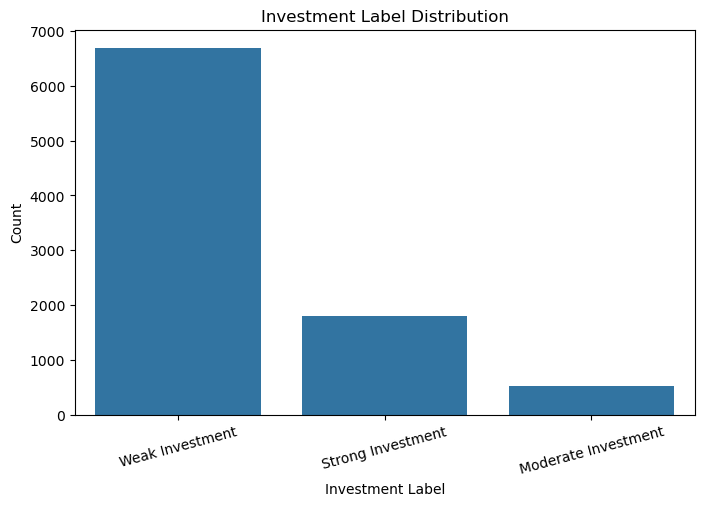

investment_label
Weak Investment       74.2500
Strong Investment     19.8900
Moderate Investment    5.8600
Name: proportion, dtype: float64

In [78]:
plt.figure(figsize=(8, 5))
sns.countplot(data=fe, x="investment_label", order=fe["investment_label"].value_counts().index)
plt.title("Investment Label Distribution")
plt.xlabel("Investment Label")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

fe["investment_label"].value_counts(normalize=True).mul(100).round(2)

### Investment Label Distribution Interpretation

The dataset shows a clear class imbalance, with **Weak Investment** dominating the majority of observations, followed by a smaller proportion of **Strong Investment**, and a very limited number of **Moderate Investment** cases.

This suggests that most properties in the dataset do not meet strong financial viability criteria, which aligns with real-world market conditions where high-quality investment opportunities are relatively rare.

The **Strong Investment** segment, while smaller, represents the most valuable opportunities in the dataset, indicating that the model will need to learn from a limited but critical subset of data. The **Moderate Investment** class is significantly underrepresented, which may lead to instability or inconsistency in how this category is learned during modeling.

Overall, the distribution confirms that the dataset reflects a realistic investment landscape but introduces imbalance that must be considered in downstream modeling.

### 9.2 Financial output validation plots

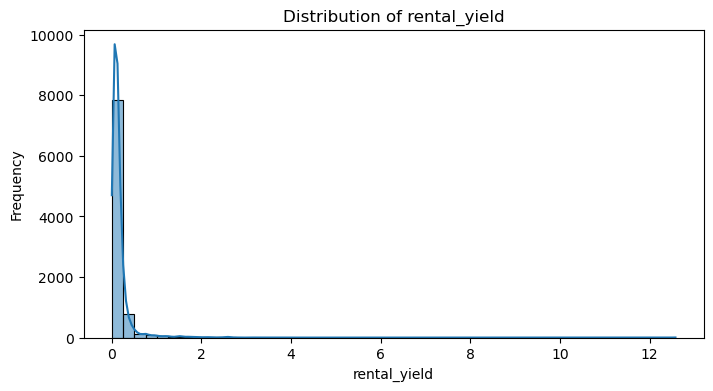

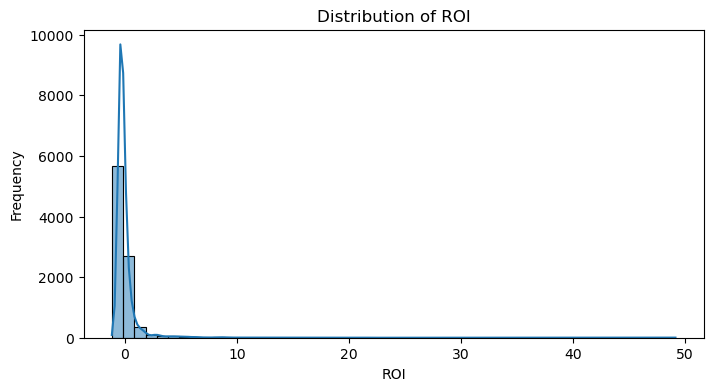

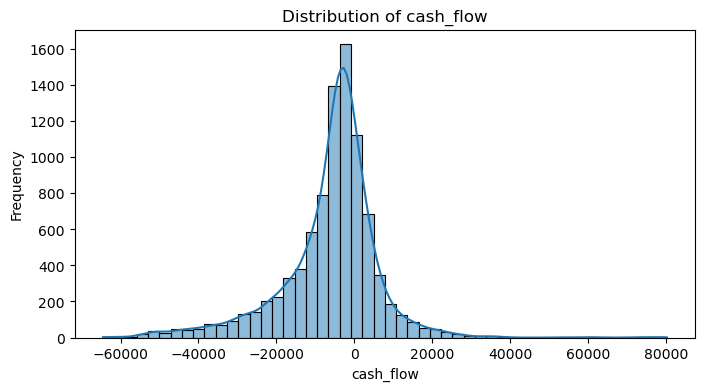

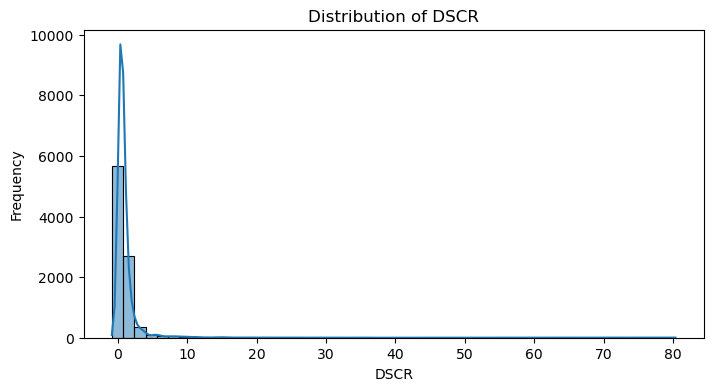

ValueError: Too many bins for data range. Cannot create 50 finite-sized bins.

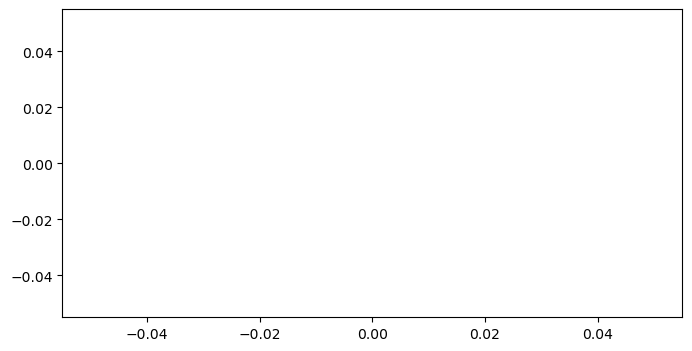

In [82]:
fig_cols = ["rental_yield", "ROI", "cash_flow", "DSCR", "ltv", "price_per_sqm", "rent_per_sqm"]

for col in fig_cols:
    if col in fe.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(fe[col], kde=True, bins=50)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

### ROI Distribution Interpretation

The ROI distribution is highly **right-skewed**, with the majority of values concentrated close to zero and a long tail extending toward very high ROI values.

This indicates that most properties generate **low to moderate returns**, while a small number of deals exhibit extremely high ROI. These extreme values are likely outliers and may be driven by unusually low purchase prices, high rental yields, or data inconsistencies.

The concentration around lower ROI levels aligns with realistic investment conditions, where high-return opportunities are rare. However, the presence of a long tail suggests potential distortion that could impact model training if not addressed.

Overall, the distribution reflects a realistic but **skewed return landscape**, with a need to carefully assess and potentially treat extreme ROI values before modeling.

### 9.3 Boxplots for outlier review

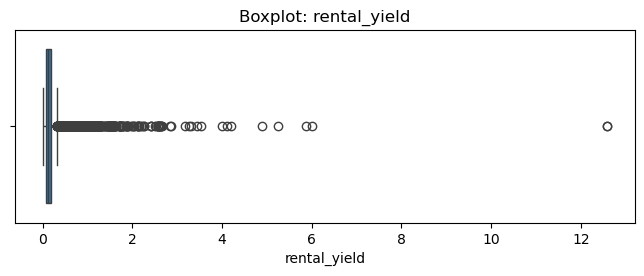

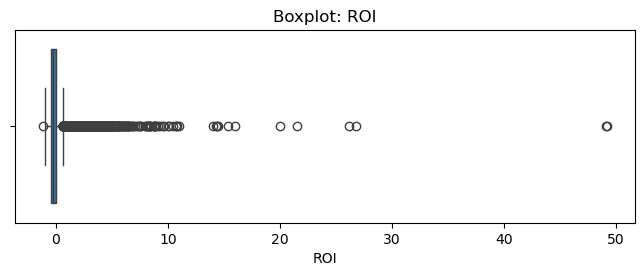

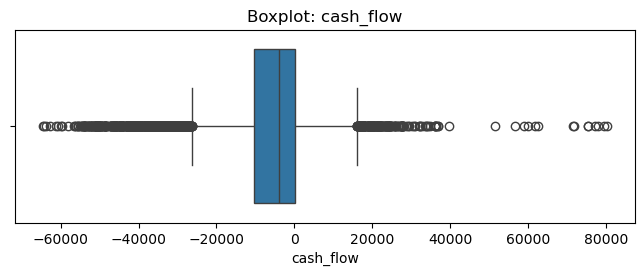

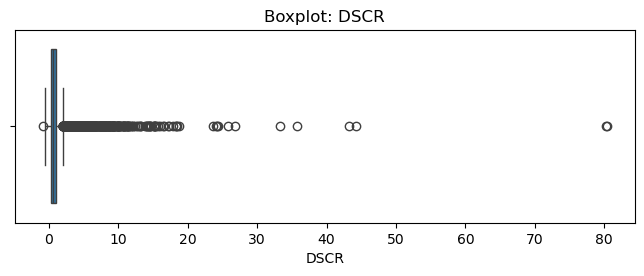

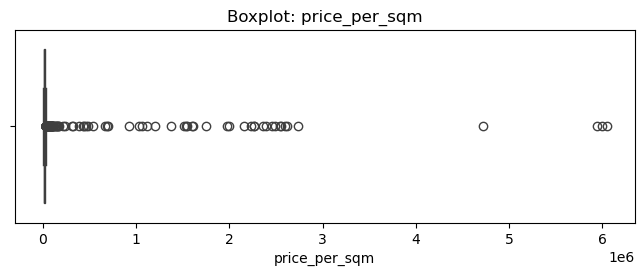

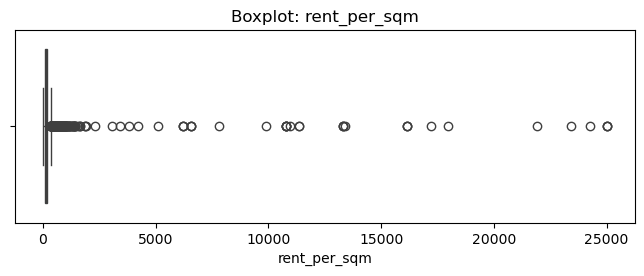

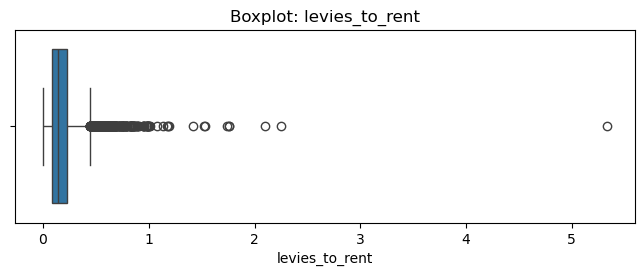

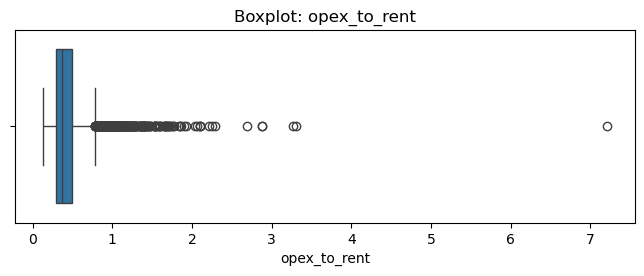

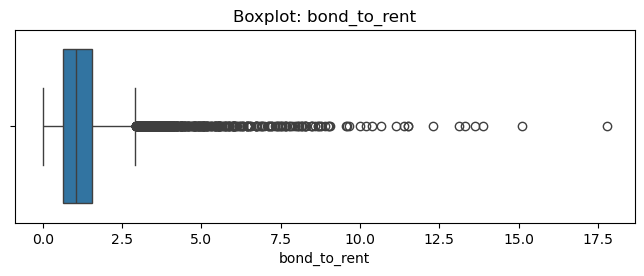

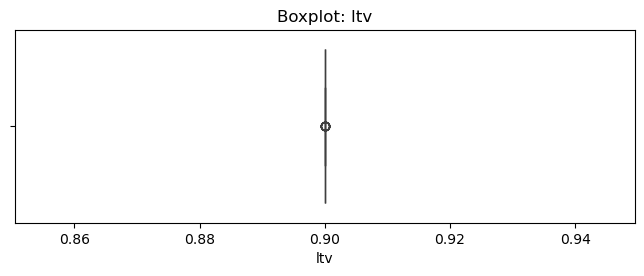

In [80]:
box_cols = [
    "rental_yield", "ROI", "cash_flow", "DSCR",
    "price_per_sqm", "rent_per_sqm", "levies_to_rent",
    "opex_to_rent", "bond_to_rent", "ltv"
]

for col in box_cols:
    if col in fe.columns:
        plt.figure(figsize=(8, 2.5))
        sns.boxplot(x=fe[col])
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.show()

### Bond-to-Rent Ratio Interpretation

The bond-to-rent ratio shows a **right-skewed distribution**, with most values concentrated within a relatively low range and a large number of high-value outliers.

The central cluster suggests that the majority of properties have a **reasonable balance between bond repayments and rental income**, which is expected in typical financed property investments.

However, the long tail of extreme values indicates the presence of properties where bond repayments are significantly higher relative to rental income. These cases likely represent **poorly performing or negatively geared investments**, or potential data anomalies.

The high density of outliers suggests substantial variability in financing efficiency across properties, which could impact model stability if not properly managed.

Overall, the feature captures meaningful financial variation but includes **extreme cases that may require further investigation or treatment** before modeling.

### 9.3 Feature separation by target


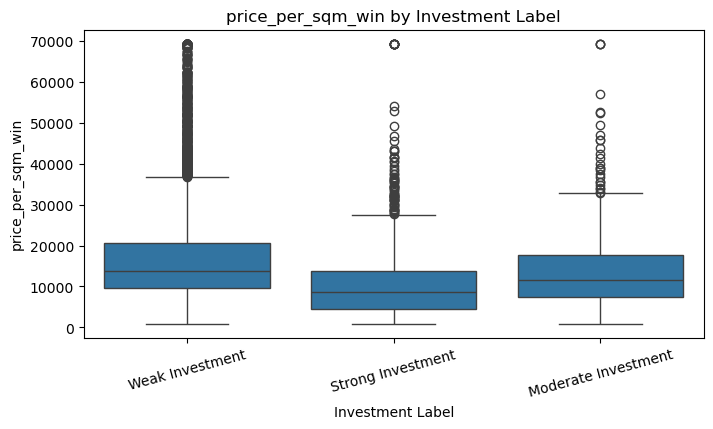

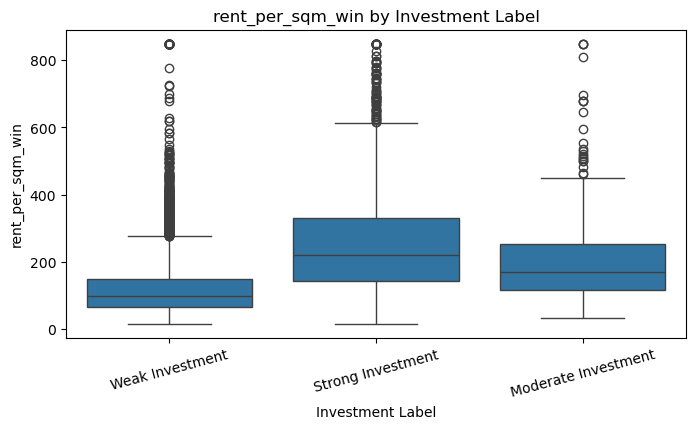

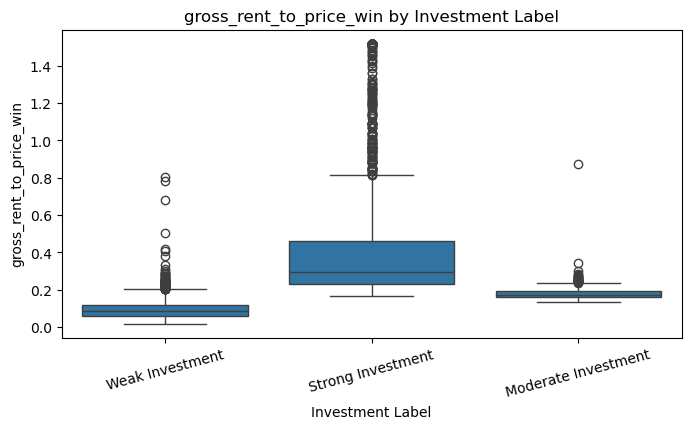

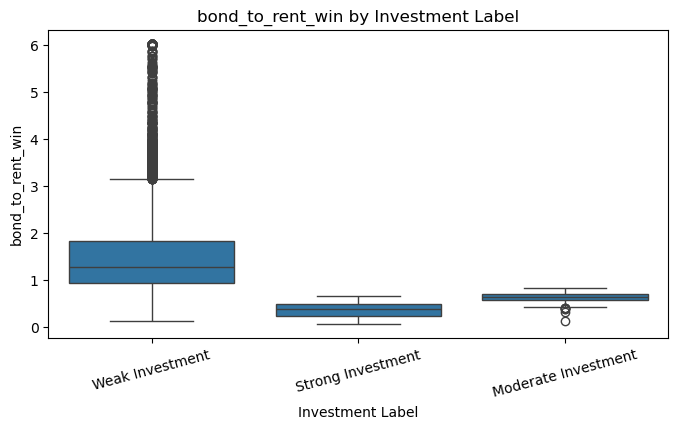

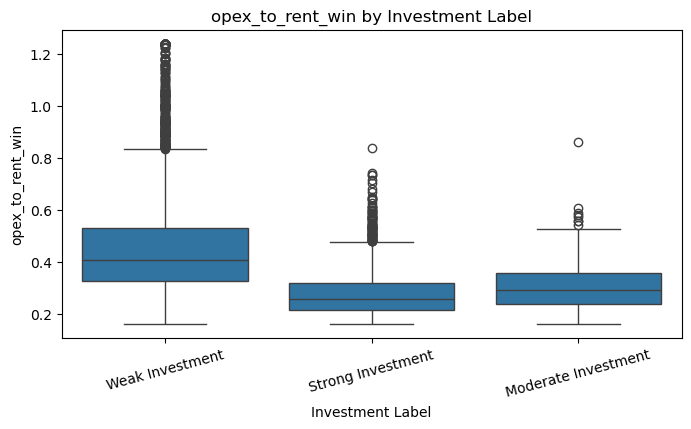

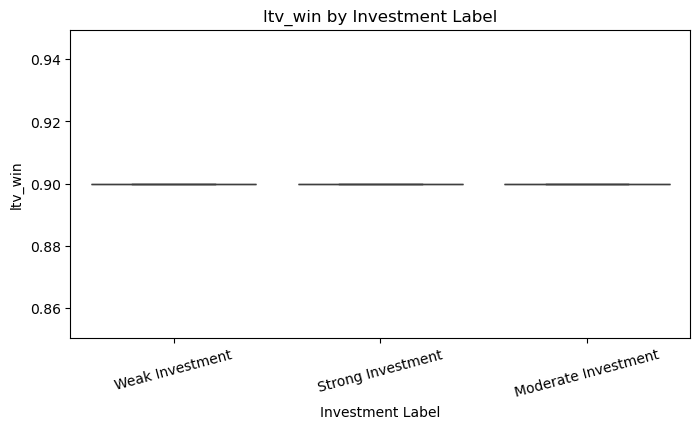

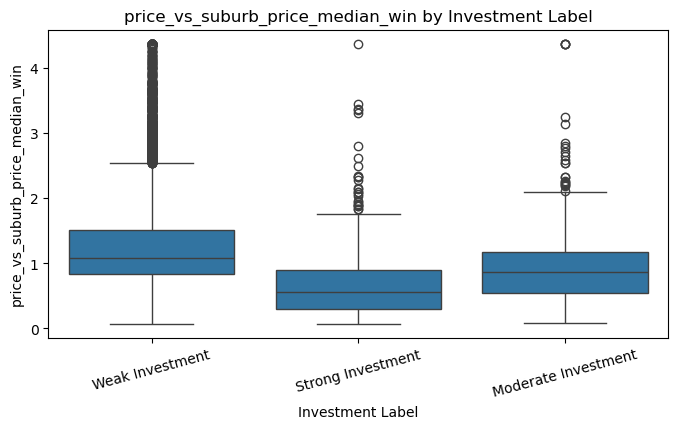

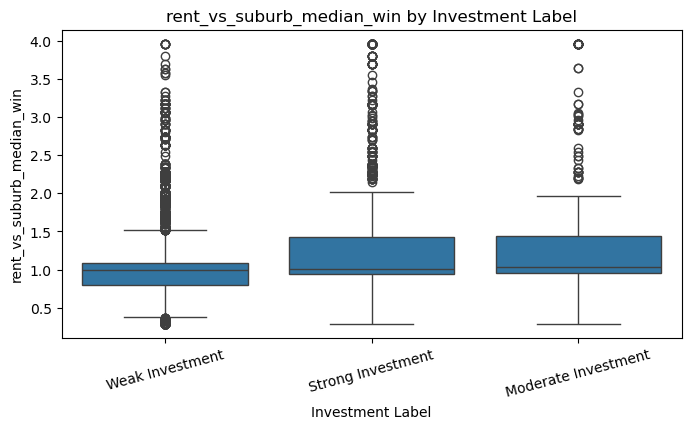

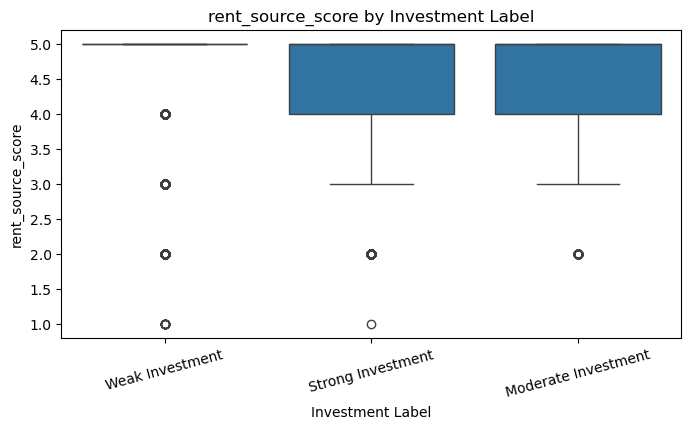

In [83]:
compare_cols = [
    "price_per_sqm_win",
    "rent_per_sqm_win",
    "gross_rent_to_price_win",
    "bond_to_rent_win",
    "opex_to_rent_win",
    "ltv_win",
    "price_vs_suburb_price_median_win",
    "rent_vs_suburb_median_win",
    "rent_source_score"
]

for col in compare_cols:
    if col in fe.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=fe, x="investment_label", y=col)
        plt.title(f"{col} by Investment Label")
        plt.xlabel("Investment Label")
        plt.ylabel(col)
        plt.xticks(rotation=15)
        plt.show()

### Rent Source Score by Investment Label Interpretation

The rent source score shows generally high values across all investment categories, with most observations clustered between scores of 4 and 5.

This indicates that the majority of rental data is derived from relatively reliable or consistent sources, regardless of investment quality. There is no strong visible separation between Weak, Moderate, and Strong investments based on this feature alone.

Weak investments appear slightly more concentrated at the highest score (5), suggesting less variability, while Strong and Moderate investments show a bit more spread toward lower scores. However, the differences are minimal.

The presence of lower-score outliers across all categories indicates occasional variability in data quality, but not in a way that clearly distinguishes investment performance.

Overall, rent_source_score does not appear to be a strong differentiating feature for investment classification on its own, but it may still contribute marginally in combination with other features.

### 9.4 Correlation heatmap

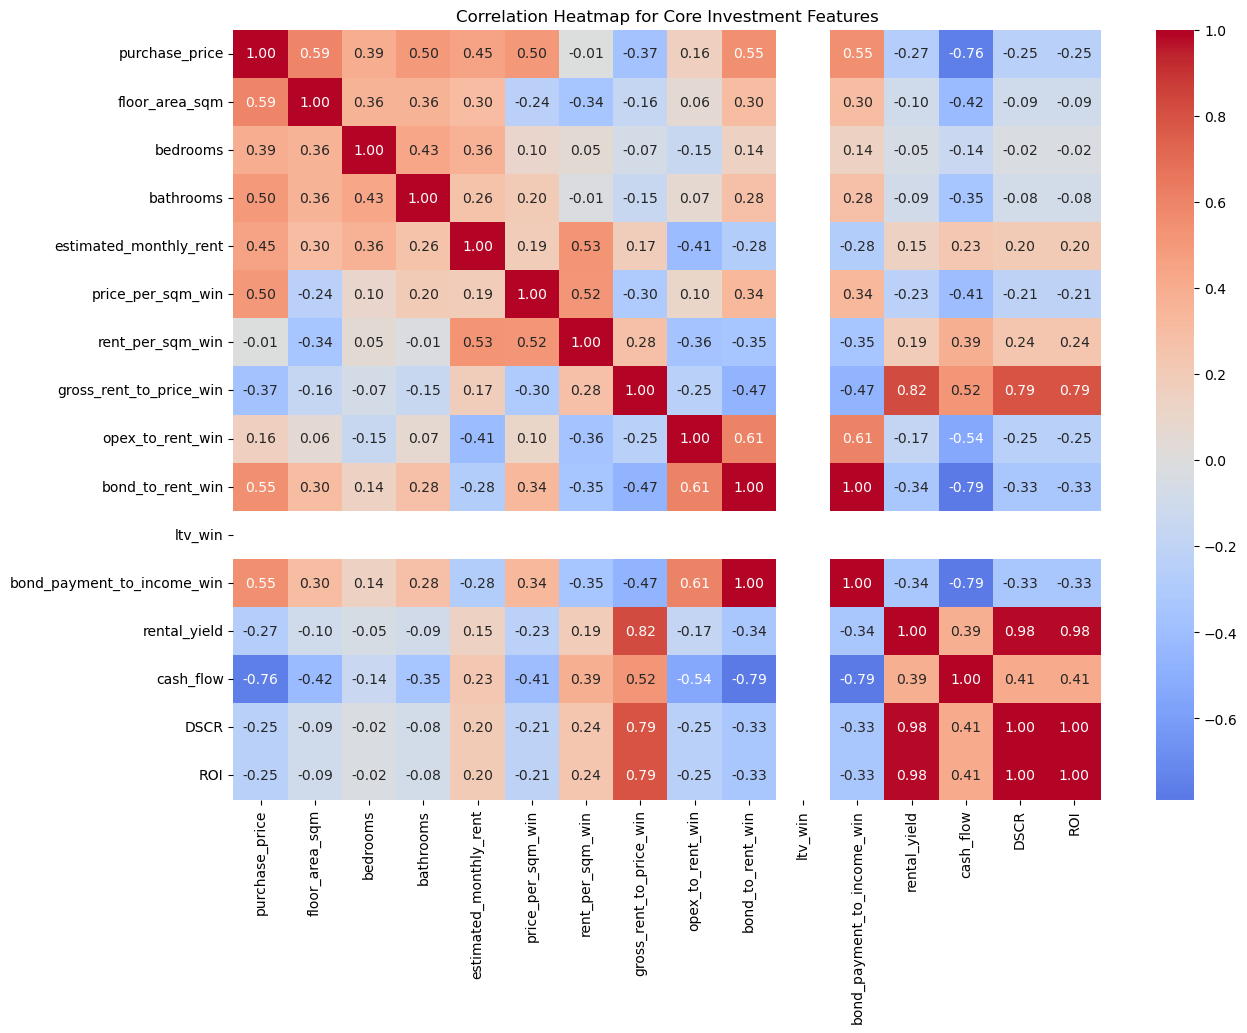

In [84]:
numeric_cols = fe.select_dtypes(include=[np.number]).columns.tolist()

corr_focus = [
    "purchase_price", "floor_area_sqm", "bedrooms", "bathrooms",
    "estimated_monthly_rent", "price_per_sqm_win", "rent_per_sqm_win",
    "gross_rent_to_price_win", "opex_to_rent_win", "bond_to_rent_win",
    "ltv_win", "bond_payment_to_income_win",
    "rental_yield", "cash_flow", "DSCR", "ROI"
]

corr_focus = [c for c in corr_focus if c in fe.columns]

plt.figure(figsize=(14, 10))
sns.heatmap(fe[corr_focus].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Core Investment Features")
plt.show()

### Correlation Heatmap Core Investment Features Interpretation

The heatmap reveals strong relationships between key financial metrics, particularly those directly tied to investment performance.

**Return-driven features are highly correlated**:  
Rental yield shows a very strong positive correlation with both ROI and DSCR (~0.98), indicating that these metrics are capturing similar underlying financial performance. This suggests potential redundancy among these variables.

**Cash flow behaves inversely to cost pressure**:  
Cash flow has strong negative correlations with bond-related metrics (e.g., bond_to_rent and bond_payment_to_income), confirming that higher financing burdens significantly reduce profitability.

**Price-related features show moderate relationships**:  
Purchase price is moderately correlated with rent, size (floor area), and bond metrics, reflecting expected market dynamics where more expensive properties tend to generate higher rents but also higher financing costs.

**Efficiency ratios provide strong signals**:  
Gross rent-to-price ratio has strong positive correlations with yield, ROI, and DSCR, reinforcing its importance as a core investment efficiency indicator.

**Limited signal from structural features**:  
Bedrooms, bathrooms, and floor area show relatively weak correlations with ROI and cash flow, suggesting that property characteristics alone are less predictive of investment performance compared to financial ratios.

Overall, the heatmap confirms that **financial engineered features drive investment outcomes**, while also highlighting potential multicollinearity among key return metrics that may need to be addressed during modeling.

### 9.5 Rent estimation confidence review

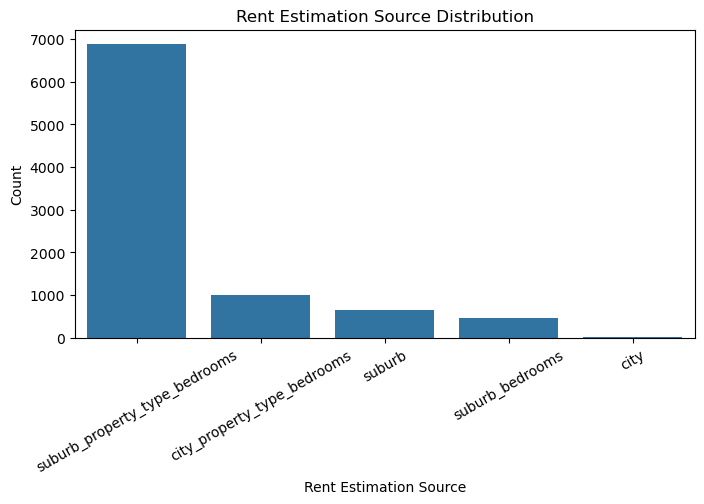

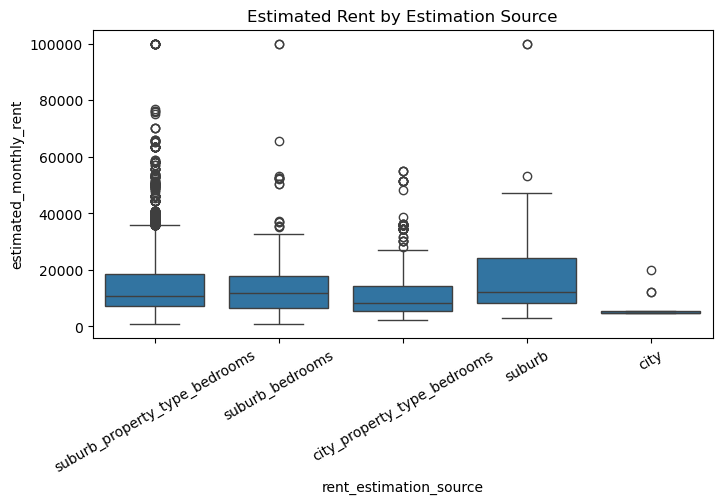

In [85]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=fe,
    x="rent_estimation_source",
    order=fe["rent_estimation_source"].value_counts().index
)
plt.title("Rent Estimation Source Distribution")
plt.xlabel("Rent Estimation Source")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=fe, x="rent_estimation_source", y="estimated_monthly_rent")
plt.title("Estimated Rent by Estimation Source")
plt.xticks(rotation=30)
plt.show()

### Rent Estimation Source Distribution Interpretation

The distribution shows that the vast majority of rent estimates are derived from **suburb + property type + bedrooms**, indicating strong reliance on **granular, locally relevant data**. This suggests that most rental estimates are grounded in high-quality, context-specific evidence.

A smaller portion of the dataset relies on **city-level + property type + bedrooms**, followed by **suburb-only** and **suburb + bedrooms** combinations. These represent fallback strategies where full feature matching was not available, implying slightly reduced estimation precision.

The **city-only** category is negligible, indicating minimal dependence on broad, low-specificity assumptions.

Overall, the dataset is predominantly driven by **strong local evidence**, with a controlled proportion of fallback logic. However, the presence of fallback-based estimates introduces variability in reliability, reinforcing the need to retain source-based confidence signals for downstream modeling.

### 9.6 Diagnostic summary tables

In [86]:
summary_cols = [
    "purchase_price",
    "estimated_monthly_rent",
    "price_per_sqm",
    "rent_per_sqm",
    "ltv",
    "bond_to_rent",
    "opex_to_rent",
    "rental_yield",
    "cash_flow",
    "DSCR",
    "ROI"
]

summary_cols = [c for c in summary_cols if c in fe.columns]

label_summary = fe.groupby("investment_label")[summary_cols].median().T
label_summary

investment_label,Moderate Investment,Strong Investment,Weak Investment
purchase_price,"976,000.0000","650,000.0000","1,346,000.0000"
estimated_monthly_rent,"14,650.0000","17,300.0000","8,900.0000"
price_per_sqm,"11,599.3612","8,595.9353","13,673.6508"
rent_per_sqm,171.1708,220.0688,99.8267
ltv,0.9000,0.9000,0.9000
bond_to_rent,0.6449,0.3784,1.2713
opex_to_rent,0.2925,0.2594,0.4064
rental_yield,0.1729,0.2946,0.0877
cash_flow,740.5386,"5,187.2385","-6,414.6851"
DSCR,1.0882,1.8938,0.4624


### Investment Label Financial Coherence Interpretation

The table shows a clear and consistent separation between investment categories, indicating that the labeling aligns well with underlying financial logic.

**Strong Investments** exhibit the most favourable metrics:
- Highest rental yield and ROI
- Strong positive cash flow
- High DSCR, indicating strong debt coverage
- Lowest bond-to-rent ratio, reflecting efficient leverage
- Highest rent efficiency (rent_per_sqm)

**Moderate Investments** fall within expected mid-range performance:
- Positive but limited cash flow
- DSCR slightly above 1, indicating borderline sustainability
- Moderate rental yield and ROI
- Balanced cost-to-rent structure

**Weak Investments** display clear financial stress signals:
- Negative cash flow
- DSCR well below 1, indicating inability to cover debt
- High bond-to-rent and opex-to-rent ratios
- Low rental yield and negative ROI
- Poor rent efficiency relative to price

Overall, the patterns confirm that:
- Strong investments are driven by **high income efficiency and low financing pressure**
- Weak investments are driven by **high cost burden and insufficient rental income**

This consistency suggests that both the **financial engine and labeling logic are coherent**, with features correctly capturing real investment dynamics.

# 10 Final Dataset Preparation and Export

At this stage, I create two final outputs from the feature engineering notebook.

### 1. Full engineered dataset
This contains:
- original financial engine columns
- engineered features
- financial outputs
- target labels

I keep this version for business interpretation, auditability, and financial review.

### 2. Model-ready dataset
This version removes:
- direct leakage variables
- identifier columns
- raw metadata fields

I keep the target column `investment_label` in this dataset so that the next notebook can split predictors and target cleanly.

I also preserve:
- categorical investment predictors such as suburb, city, province, and property type
- missingness flags
- winsorised ratio versions for modelling stability

This keeps the dataset aligned to the real project objective:
predicting financed property investment quality without leaking the spreadsheet logic into the model.

In [88]:
full_engineered_df = fe.copy()
model_ready_df = fe.copy()

### 10.1 HELPER FUNCTION: WINSORISATION

In [89]:

def winsorize_series(s, lower=0.01, upper=0.99):
    """
    Caps extreme values at the selected quantiles.
    This is mainly useful for unstable ratio features.
    """
    s = pd.to_numeric(s, errors="coerce")
    
    if s.dropna().empty:
        return s
    
    lower_q = s.quantile(lower)
    upper_q = s.quantile(upper)
    
    return s.clip(lower=lower_q, upper=upper_q)

### 10.2 CREATE WINSORISED VERSIONS OF RATIO FEATURES

In [90]:
# These are raw ratio features created earlier in the feature engineering section.
# I keep both raw and winsorised versions:
# - raw for interpretation
# - winsorised for modelling stability

winsor_cols = [
    "price_per_sqm",
    "price_per_land_sqm",
    "rent_per_sqm",
    "gross_rent_to_price",
    "monthly_rent_to_price",
    "levies_to_rent",
    "rates_to_rent",
    "bond_to_rent",
    "opex_to_rent",
    "cash_flow_margin",
    "ltv",
    "bond_payment_to_income",
    "debt_service_headroom",
    "price_per_sqm_vs_local_median",
    "rent_vs_suburb_median",
    "rent_vs_city_median",
    "price_vs_suburb_price_median",
    "price_vs_city_price_median"
]

for col in winsor_cols:
    if col in model_ready_df.columns:
        model_ready_df[f"{col}_win"] = winsorize_series(model_ready_df[col])

### 10.3. CREATE / VALIDATE RENT ESTIMATION CONFIDENCE FEATURES

In [91]:
# This project depends heavily on estimated rent.
# So I explicitly keep a confidence signal showing how strong the rent evidence was.

source_rank = {
    "suburb_property_type_bedrooms": 5,
    "suburb_bedrooms": 4,
    "suburb": 3,
    "city_property_type_bedrooms": 2,
    "city": 1
}

if "rent_estimation_source" in model_ready_df.columns:
    model_ready_df["rent_source_score"] = (
        model_ready_df["rent_estimation_source"]
        .map(source_rank)
        .fillna(0)
    )

### 10. 4. CREATE MISSINGNESS FLAGS

In [92]:
# I do not impute here.
# Imputation must happen later inside the modelling pipeline,
# fitted only on the training set.

for col in model_ready_df.columns:
    if model_ready_df[col].isna().sum() > 0:
        model_ready_df[f"{col}_missing_flag"] = model_ready_df[col].isna().astype(int)

### 10.5. DEFINE TARGET

In [93]:
target_col = "investment_label"

if target_col not in model_ready_df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe.")

y = model_ready_df[target_col].copy()

### 6. REMOVE LEAKAGE COLUMNS

In [94]:
# These are downstream financial outputs or near-direct target logic.
# They must not be used as predictors when predicting investment_label.

direct_leakage_cols = [
    "NOI",
    "cash_flow",
    "DSCR",
    "annual_cash_flow",
    "rental_yield",
    "ROI",
    "equity_12m",
    "payments_made_12m",
    "remaining_balance_12m"
]

derived_from_outputs_cols = [
    "noi_margin",
    "cash_flow_margin",
    "cash_flow_to_cash_invested",
    "equity_12m_to_cash_invested",
    "debt_service_headroom",
    "positive_cash_flow_flag",
    "dscr_above_one_flag",
    "dscr_above_1_2_flag",
    "bond_payment_to_noi"
]

leakage_cols = direct_leakage_cols + derived_from_outputs_cols

model_ready_df = model_ready_df.drop(
    columns=[col for col in leakage_cols if col in model_ready_df.columns],
    errors="ignore"
)

### 10.7. REMOVE NON-MODELLING IDENTIFIER / METADATA COLUMNS

In [95]:
# These are not stable predictors for the structured baseline model.
# I keep suburb, city, province, and property_type because they ARE useful features.

id_cols = [
    "source_site",
    "listing_id",
    "listing_url",
    "title",
    "description",
    "listing_date",
    "scraped_timestamp",
    "pp_transaction_slug",
    "pp_province_slug",
    "pp_metro_slug",
    "pp_city_slug",
    "pp_suburb_slug"
]

model_ready_df = model_ready_df.drop(
    columns=[col for col in id_cols if col in model_ready_df.columns],
    errors="ignore"
)

###  10.8. FINAL COLUMN ORDERING

In [96]:
# Keep target in the model-ready dataset for downstream notebook use
# while still allowing easy separation into X and y later.

predictor_cols = [col for col in model_ready_df.columns if col != target_col]
model_ready_df = model_ready_df[predictor_cols + [target_col]]

#### 10.9. FINAL SANITY CHECK

In [97]:
print("Full engineered dataset shape :", full_engineered_df.shape)
print("Model-ready dataset shape     :", model_ready_df.shape)

print("\nTop missing columns in model-ready dataset:")
print(
    model_ready_df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("\nTarget distribution:")
print(model_ready_df[target_col].value_counts(dropna=False))

Full engineered dataset shape : (9009, 171)
Model-ready dataset shape     : (9009, 171)

Top missing columns in model-ready dataset:
rent_mean_suburb_type_bed               2133
rent_dispersion_suburb_type_bed         2133
rent_vs_suburb_type_bed_median          2133
rent_count_suburb_type_bed              2133
rent_median_suburb_type_bed             2133
rent_vs_suburb_bed_median               1672
rent_count_suburb_bed                   1672
rent_mean_suburb_bed                    1672
rent_median_suburb_bed                  1672
rent_vs_suburb_median_win               1020
rent_vs_suburb_median                   1020
price_vs_suburb_median_rent_multiple    1020
rent_count_suburb                       1020
rent_mean_suburb                        1020
rent_median_suburb                      1020
rent_dispersion_suburb                  1020
rent_per_bedroom                         670
price_per_bedroom                        670
parking_per_bedroom                      670
garage      

# 11. EXPORT DATASETS

In [98]:
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

full_path = output_dir / "financial_engine_feature_engineered_full.csv"
model_path = output_dir / "financial_engine_feature_engineered_model_ready.csv"

full_engineered_df.to_csv(full_path, index=False)
model_ready_df.to_csv(model_path, index=False)

print(f"\nSaved full engineered dataset to   : {full_path}")
print(f"Saved model-ready dataset to       : {model_path}")
print("✅ Datasets exported successfully")


Saved full engineered dataset to   : data\processed\financial_engine_feature_engineered_full.csv
Saved model-ready dataset to       : data\processed\financial_engine_feature_engineered_model_ready.csv
✅ Datasets exported successfully
